In [1]:
# ============================================
# 1. INSTALL AND IMPORT LIBRARIES
# ============================================

!pip install yfinance tensorflow scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, LSTM, GRU, Dropout, Conv1D, MaxPooling1D, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================
# 2. DOWNLOAD AND PREPARE DATA
# ============================================

stock_ticker = "AAPL"

# Download stock data
stock_data = yf.download(
    stock_ticker,
    start="2015-01-01",
    end="2024-12-31"
)

[*********************100%***********************]  1 of 1 completed


In [3]:
# Use only Close prices
stock_data = stock_data[["Close"]]

print("Dataset shape:", stock_data.shape)
print("\nFirst 5 rows:")
print(stock_data.head())
print("\nLast 5 rows:")
print(stock_data.tail())

Dataset shape: (2515, 1)

First 5 rows:
Price           Close
Ticker           AAPL
Date                 
2015-01-02  24.192602
2015-01-05  23.511055
2015-01-06  23.513281
2015-01-07  23.842978
2015-01-08  24.759079

Last 5 rows:
Price            Close
Ticker            AAPL
Date                  
2024-12-23  253.649414
2024-12-24  256.560852
2024-12-26  257.375580
2024-12-27  253.967392
2024-12-30  250.598892


In [4]:
# Save to CSV
stock_data.to_csv("apple_stock_data.csv")
print("\nDataset saved successfully")


Dataset saved successfully


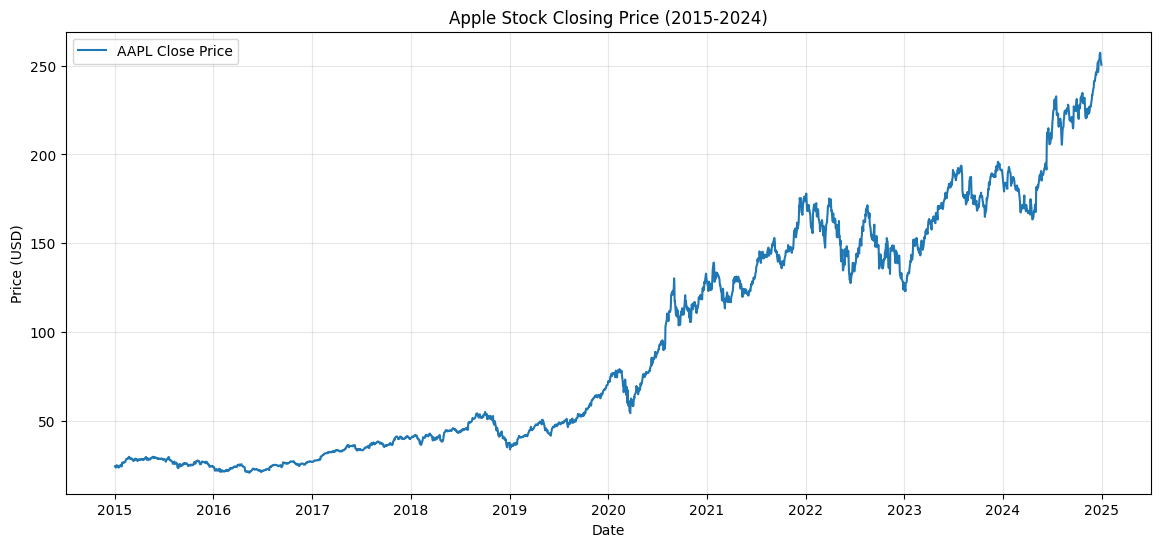

In [5]:
# Visualize the data
plt.figure(figsize=(14,6))
plt.plot(stock_data['Close'], label='AAPL Close Price')
plt.title('Apple Stock Closing Price (2015-2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# ============================================
# 3. TRAIN-TEST SPLIT AND SCALING (NO DATA LEAKAGE)
# ============================================

# Split data BEFORE scaling to prevent data leakage
train_size = int(len(stock_data) * 0.8)
train_data = stock_data.iloc[:train_size]
test_data = stock_data.iloc[train_size:]

print(f"\nTraining data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")

# Scale separately - fit ONLY on training data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)


Training data size: 2012
Testing data size: 503


In [7]:
# ============================================
# 4. CREATE SEQUENCES FOR TIME SERIES
# ============================================

sequence_length = 60  # Use 60 days to predict next day

def create_sequences(data, seq_length):
    """
    Create sequences for time series prediction

    Args:
        data: Scaled numpy array
        seq_length: Number of previous time steps to use

    Returns:
        X: Input sequences
        y: Target values
    """
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Create sequences
X_train, y_train = create_sequences(scaled_train, sequence_length)
X_test, y_test = create_sequences(scaled_test, sequence_length)

# Reshape for deep learning models (samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (1952, 60, 1)
y_train shape: (1952,)
X_test shape: (443, 60, 1)
y_test shape: (443,)


In [8]:
# ============================================
# 5. CALLBACKS FOR BETTER TRAINING
# ============================================

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [9]:
# Reduce learning rate when plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)


In [10]:
# ============================================
# 6. MODEL 1: LSTM
# ============================================

print("\n" + "="*50)
print("TRAINING LSTM MODEL")
print("="*50)

lstm_model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


TRAINING LSTM MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - loss: 0.0158 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0023 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0019 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0016 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0020 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0016 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0016 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0019 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 9/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0018 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 10/50
60/61

In [11]:
# ============================================
# 7. MODEL 2: GRU
# ============================================

print("\n" + "="*50)
print("TRAINING GRU MODEL")
print("="*50)

gru_model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

gru_model.summary()

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


TRAINING GRU MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,889 (148.00 KB)

 Trainable params: 37,889 (148.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 0.0144 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0020 - val_loss: 6.7030e-04 - learning_rate: 0.0010
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0018 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0016 - val_loss: 7.2411e-04 - learning_rate: 0.0010
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0017 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - loss: 0.0015 - val_loss: 6.5665e-04 - learning_rate: 0.0010
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0015
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0015 - val_loss: 6.7825e-04 - learning_rate: 0.0010
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0015 - val_loss: 7.0794e-04 -

In [12]:
# ============================================
# 8. MODEL 3: CNN + LSTM (Hybrid)
# ============================================

print("\n" + "="*50)
print("TRAINING CNN + LSTM MODEL")
print("="*50)

cnn_lstm_model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

cnn_lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

cnn_lstm_model.summary()

cnn_lstm_history = cnn_lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


TRAINING CNN + LSTM MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,345 (130.25 KB)

 Trainable params: 33,345 (130.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0139 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0022 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0021 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0018 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0019
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0018 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0016 - val_loss: 0.0055 - learning_rate: 5.0000e-04
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0017 - val_loss: 0.0023 - learning_rate: 5.0000e-04
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0014 - val_loss: 0.0060 - learning_ra

In [13]:
# ============================================
# 9. EVALUATION FUNCTION WITH MULTIPLE METRICS
# ============================================

def calculate_metrics(actual, predictions):
    """
    Calculate multiple evaluation metrics

    Args:
        actual: Actual values
        predictions: Predicted values

    Returns:
        Dictionary with various metrics
    """
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mae = mean_absolute_error(actual, predictions)
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    r2 = r2_score(actual, predictions)

    return {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R² Score': r2
    }

def predict_and_evaluate(model, X_test, y_test, scaler, model_name):
    """
    Make predictions and evaluate model performance
    """
    # Make predictions
    predictions = model.predict(X_test, verbose=0)

    # Inverse transform to get actual prices
    predictions = scaler.inverse_transform(predictions)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calculate metrics
    metrics = calculate_metrics(actual, predictions)

    print(f"\n{'='*40}")
    print(f"{model_name} RESULTS")
    print(f"{'='*40}")
    for metric_name, value in metrics.items():
        print(f"{metric_name:10}: {value:.4f}")

    return actual, predictions, metrics

# Evaluate all models
lstm_actual, lstm_pred, lstm_metrics = predict_and_evaluate(
    lstm_model, X_test, y_test, scaler, "LSTM"
)

gru_actual, gru_pred, gru_metrics = predict_and_evaluate(
    gru_model, X_test, y_test, scaler, "GRU"
)

cnn_actual, cnn_pred, cnn_metrics = predict_and_evaluate(
    cnn_lstm_model, X_test, y_test, scaler, "CNN+LSTM"
)


LSTM RESULTS
RMSE      : 7.4167
MAE       : 5.7208
MAPE (%)  : 2.8627
R² Score  : 0.9069

GRU RESULTS
RMSE      : 4.0145
MAE       : 3.1395
MAPE (%)  : 1.6103
R² Score  : 0.9727

CNN+LSTM RESULTS
RMSE      : 9.2275
MAE       : 7.4748
MAPE (%)  : 3.7272
R² Score  : 0.8559


In [14]:
# ============================================
# 10. COMPARE RESULTS
# ============================================

# Create comparison dataframe
results_df = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'CNN+LSTM'],
    'RMSE': [lstm_metrics['RMSE'], gru_metrics['RMSE'], cnn_metrics['RMSE']],
    'MAE': [lstm_metrics['MAE'], gru_metrics['MAE'], cnn_metrics['MAE']],
    'MAPE (%)': [lstm_metrics['MAPE (%)'], gru_metrics['MAPE (%)'], cnn_metrics['MAPE (%)']],
    'R² Score': [lstm_metrics['R² Score'], gru_metrics['R² Score'], cnn_metrics['R² Score']]
})

results_df = results_df.sort_values(by='RMSE')
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(results_df.to_string(index=False))



MODEL COMPARISON SUMMARY
   Model     RMSE      MAE  MAPE (%)  R² Score
     GRU 4.014514 3.139521  1.610267  0.972725
    LSTM 7.416727 5.720848  2.862746  0.906907
CNN+LSTM 9.227501 7.474762  3.727221  0.855901


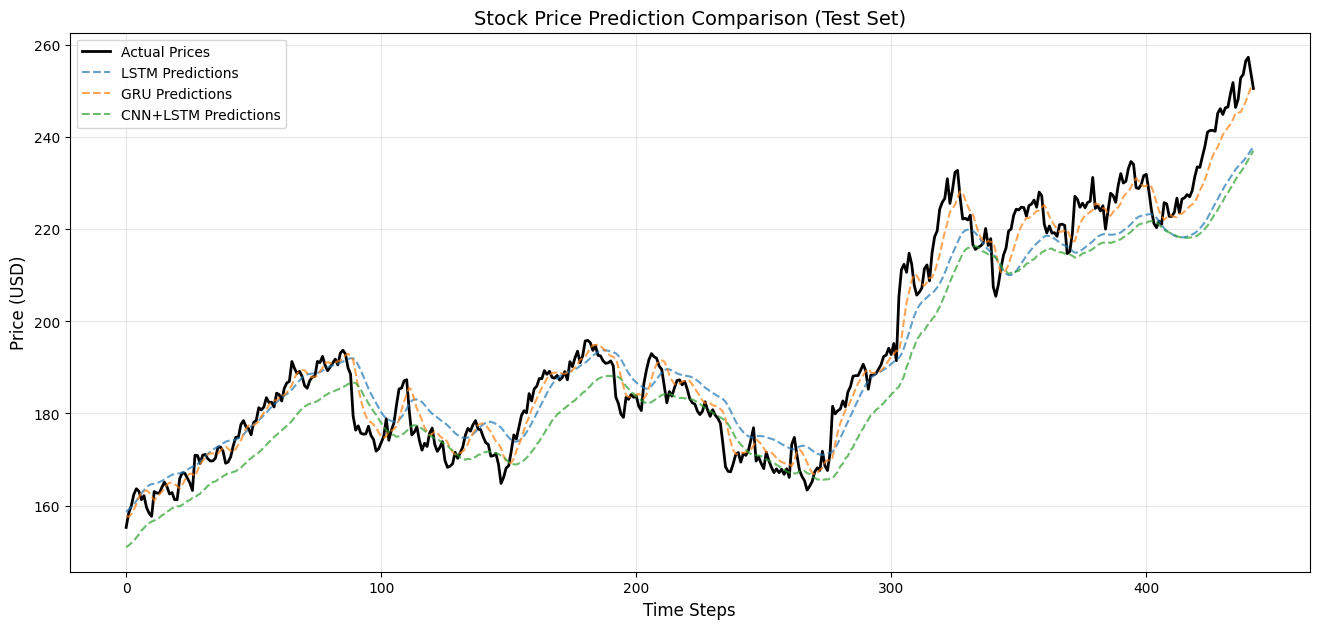

In [15]:
# ============================================
# 11. VISUALIZATION
# ============================================

# 11.1 Stock Price Prediction Comparison
plt.figure(figsize=(16, 7))

# Plot actual vs predictions
plt.plot(lstm_actual, label='Actual Prices', linewidth=2, color='black')
plt.plot(lstm_pred, label='LSTM Predictions', alpha=0.7, linestyle='--')
plt.plot(gru_pred, label='GRU Predictions', alpha=0.7, linestyle='--')
plt.plot(cnn_pred, label='CNN+LSTM Predictions', alpha=0.7, linestyle='--')

plt.title('Stock Price Prediction Comparison (Test Set)', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


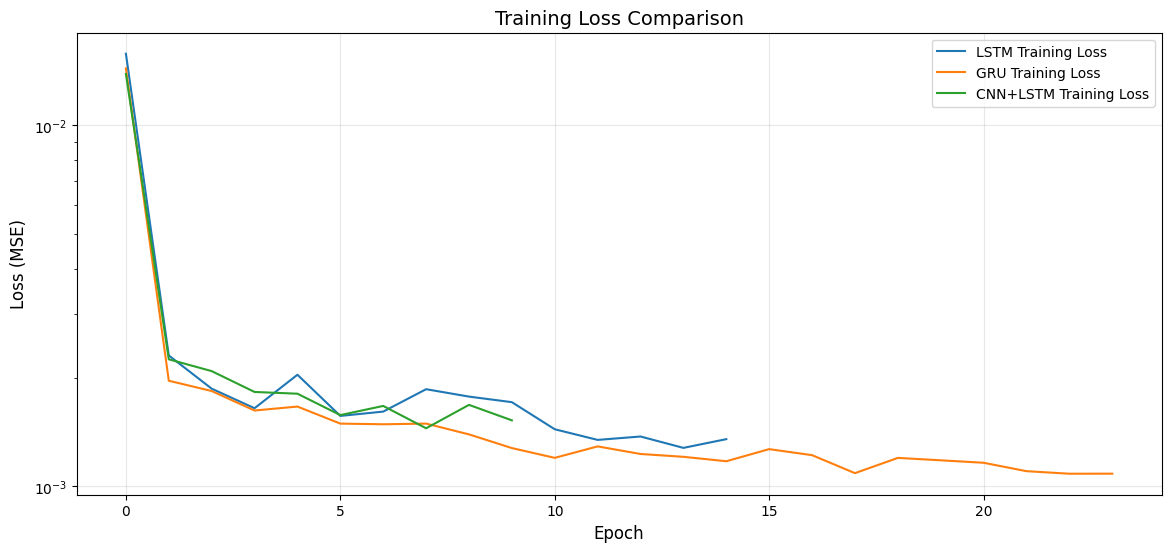

In [16]:
# 11.2 Training Loss Comparison
plt.figure(figsize=(14, 6))

plt.plot(lstm_history.history['loss'], label='LSTM Training Loss', linewidth=1.5)
plt.plot(gru_history.history['loss'], label='GRU Training Loss', linewidth=1.5)
plt.plot(cnn_lstm_history.history['loss'], label='CNN+LSTM Training Loss', linewidth=1.5)

plt.title('Training Loss Comparison', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale for better visualization
plt.show()

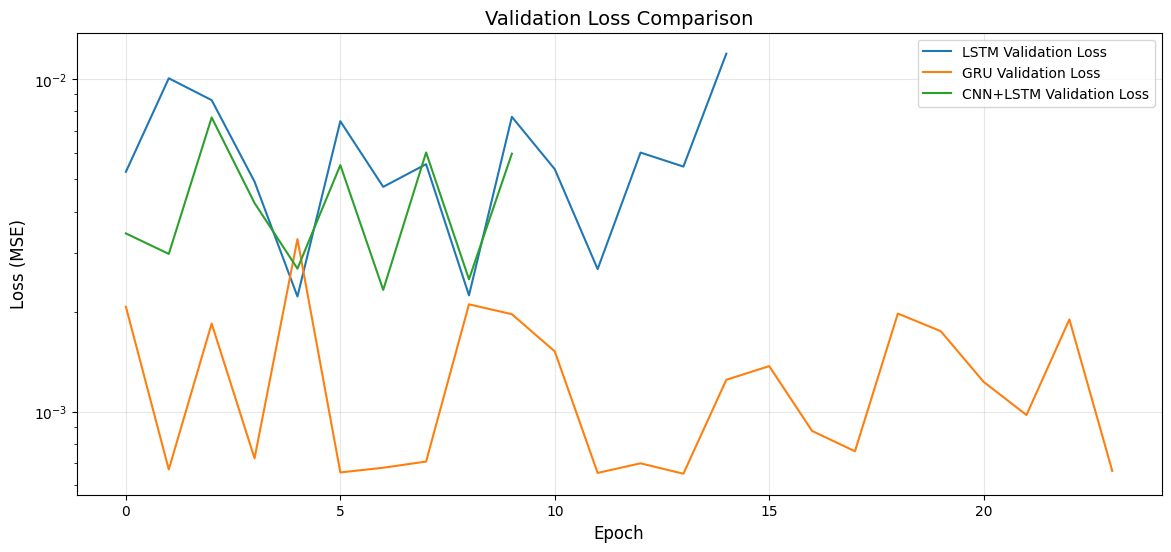

In [17]:
# 11.3 Validation Loss Comparison
plt.figure(figsize=(14, 6))

plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss', linewidth=1.5)
plt.plot(gru_history.history['val_loss'], label='GRU Validation Loss', linewidth=1.5)
plt.plot(cnn_lstm_history.history['val_loss'], label='CNN+LSTM Validation Loss', linewidth=1.5)

plt.title('Validation Loss Comparison', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

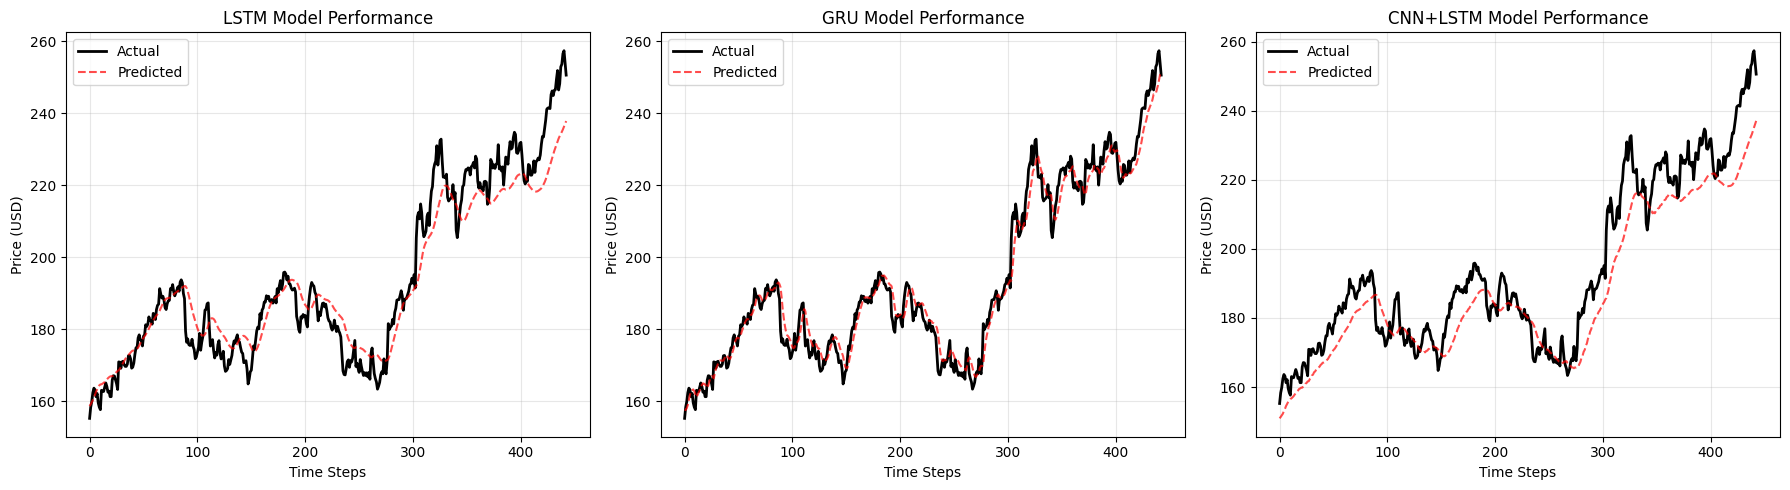

In [18]:
# 11.4 Individual Model Performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (lstm_actual, lstm_pred, 'LSTM'),
    (gru_actual, gru_pred, 'GRU'),
    (cnn_actual, cnn_pred, 'CNN+LSTM')
]

for idx, (actual, pred, name) in enumerate(models):
    axes[idx].plot(actual, label='Actual', linewidth=2, color='black')
    axes[idx].plot(pred, label='Predicted', alpha=0.7, linestyle='--', color='red')
    axes[idx].set_title(f'{name} Model Performance', fontsize=12)
    axes[idx].set_xlabel('Time Steps')
    axes[idx].set_ylabel('Price (USD)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

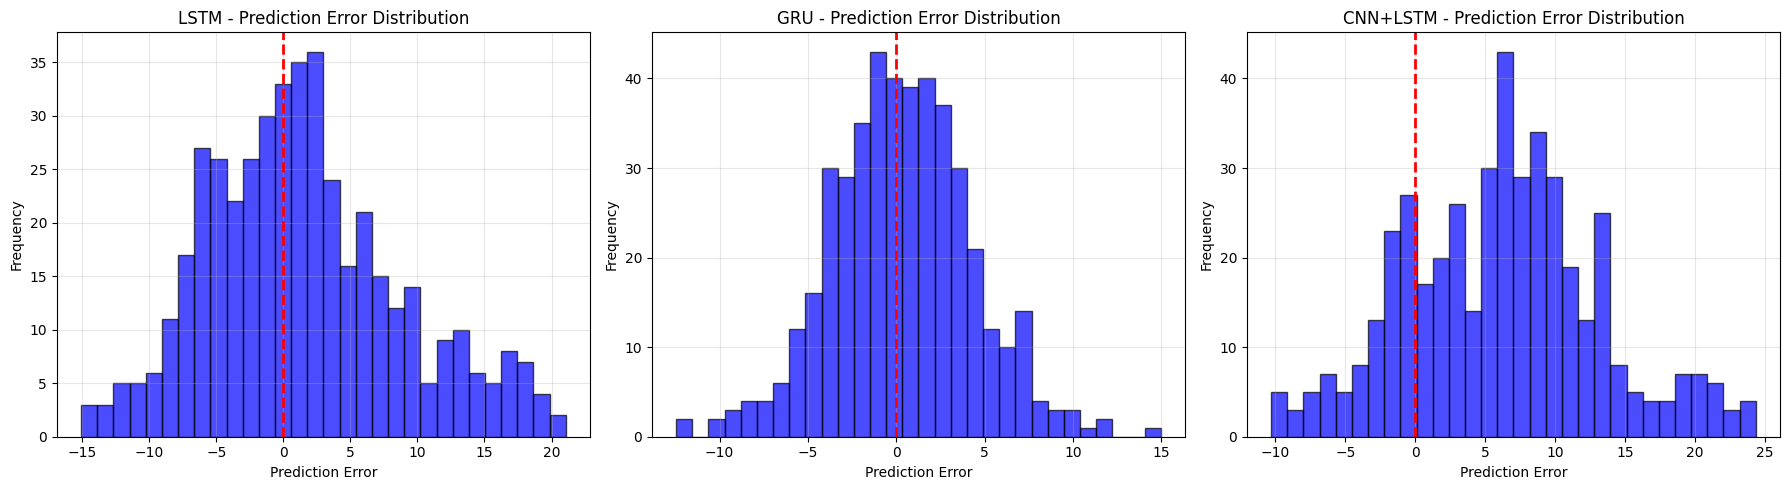

In [19]:
# 11.5 Prediction Error Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

errors = [
    (lstm_actual.flatten() - lstm_pred.flatten(), 'LSTM'),
    (gru_actual.flatten() - gru_pred.flatten(), 'GRU'),
    (cnn_actual.flatten() - cnn_pred.flatten(), 'CNN+LSTM')
]

for idx, (error, name) in enumerate(errors):
    axes[idx].hist(error, bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'{name} - Prediction Error Distribution', fontsize=12)
    axes[idx].set_xlabel('Prediction Error')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
# ============================================
# 12. BEST MODEL SELECTION
# ============================================

best_model_name = results_df.iloc[0]['Model']
best_rmse = results_df.iloc[0]['RMSE']

print("\n" + "="*50)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   RMSE: {best_rmse:.4f}")
print(f"   MAE: {results_df.iloc[0]['MAE']:.4f}")
print(f"   MAPE: {results_df.iloc[0]['MAPE (%)']:.2f}%")
print(f"   R² Score: {results_df.iloc[0]['R² Score']:.4f}")
print("="*50)


🏆 BEST MODEL: GRU
   RMSE: 4.0145
   MAE: 3.1395
   MAPE: 1.61%
   R² Score: 0.9727


In [21]:
# ============================================
# 13. SAVE MODELS
# ============================================

# Save models in native Keras format (recommended)
lstm_model.save('lstm_model.keras')
gru_model.save('gru_model.keras')
cnn_lstm_model.save('cnn_lstm_model.keras')

print("\n✅ All models saved successfully as .keras files")
print("   - lstm_model.keras")
print("   - gru_model.keras")
print("   - cnn_lstm_model.keras")

# Also save scaler for future use
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as scaler.pkl")



✅ All models saved successfully as .keras files
   - lstm_model.keras
   - gru_model.keras
   - cnn_lstm_model.keras
✅ Scaler saved as scaler.pkl


In [22]:
# ============================================
# 14. ADDITIONAL: PREDICTION FOR NEXT DAY
# ============================================

def predict_next_day(model, last_sequence, scaler):
    """
    Predict the next day's price
    """
    last_sequence = last_sequence.reshape((1, last_sequence.shape[0], 1))
    next_pred_scaled = model.predict(last_sequence, verbose=0)
    next_pred = scaler.inverse_transform(next_pred_scaled)
    return next_pred[0, 0]

# Use last 60 days from test set to predict next day
last_60_days = X_test[-1].reshape(60, 1)
next_day_lstm = predict_next_day(lstm_model, last_60_days, scaler)
next_day_gru = predict_next_day(gru_model, last_60_days, scaler)
next_day_cnn = predict_next_day(cnn_lstm_model, last_60_days, scaler)

print("\n" + "="*50)
print("NEXT DAY PRICE PREDICTIONS")
print("="*50)
print(f"LSTM Prediction:     ${next_day_lstm:.2f}")
print(f"GRU Prediction:      ${next_day_gru:.2f}")
print(f"CNN+LSTM Prediction: ${next_day_cnn:.2f}")
print(f"Ensemble Average:    ${(next_day_lstm + next_day_gru + next_day_cnn)/3:.2f}")




NEXT DAY PRICE PREDICTIONS
LSTM Prediction:     $237.83
GRU Prediction:      $251.10
CNN+LSTM Prediction: $237.06
Ensemble Average:    $242.00


In [23]:
# ============================================
# 15. SUMMARY STATISTICS
# ============================================

print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"📊 Total Data Points: {len(stock_data)}")
print(f"📈 Training Data: {len(train_data)} ({train_size*100:.0f}%)")
print(f"📉 Testing Data: {len(test_data)} ({(1-train_size)*100:.0f}%)")
print(f"🕐 Sequence Length: {sequence_length} days")
print(f"🎯 Best Performing Model: {best_model_name}")
print(f"✅ All models trained without data leakage")
print("="*50)


FINAL SUMMARY
📊 Total Data Points: 2515
📈 Training Data: 2012 (201200%)
📉 Testing Data: 503 (-201100%)
🕐 Sequence Length: 60 days
🎯 Best Performing Model: GRU
✅ All models trained without data leakage
